# 📊 Data Wrangling & Feature Engineering — Job Posting Indonesia
**Project:** Workaholic — CC26-PSU105  
**Tema:** Future Ready Work and Economy  
**Dataset:** Jobstreet Indonesia

---

## 📊 Info Dataset
| File | Sumber | Baris | Keterangan |
|---|---|---|---|
| `job_posting_indonesia.csv` | Jobstreet Indonesia (Kaggle) | 623.610 | Data mentah |
| `df_model.csv` | Output notebook ini | ~138.000 | Siap training model |
| `df_salary.csv` | Output notebook ini | ~58.487 | Siap estimasi gaji |

##  Pertanyaan Bisnis
1. Kategori pekerjaan apa yang paling banyak dibutuhkan di Indonesia 
   berdasarkan data lowongan 2021-2022, dan apakah dominasi kategori 
   tersebut konsisten di semua kota besar?

2. Kota mana yang paling banyak membuka lowongan kerja di Indonesia 
   berdasarkan data 2021-2022, dan bagaimana persebarannya dibandingkan 
   dengan kota-kota di luar Pulau Jawa?

3. Bagaimana perbandingan rata-rata kisaran gaji antar kategori pekerjaan 
   di Indonesia berdasarkan data 2021-2022, dan kategori mana yang 
   menawarkan gap terbesar antara gaji minimum dan maksimum?

4. Apakah tipe pekerjaan (Full-time, Contract, Internship) 
   berpengaruh terhadap kisaran gaji yang ditawarkan pada kategori 
   yang sama?
   
5. Bagaimana distribusi lowongan kerja berdasarkan tipe 
   pekerjaan, dan apakah ada perbedaan signifikan antar kota?

---
## 🔧 Bagian 1 — Import Library

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Data Wrangling

### 📥 Gathering Data

Dataset yang digunakan adalah **Jobstreet Indonesia Dataset**
dari Kaggle (azizainunnajib/jobs-crawling), hasil crawling
lowongan kerja di Jobstreet Indonesia periode 2021–2022.
File digabung menjadi `job_posting_indonesia.csv` dengan
total **623.610 baris** dan **24 kolom**.

**Kolom utama yang digunakan:**
- `jobTitle` — judul pekerjaan
- `companyName` — nama perusahaan
- `categoriesName` — kategori/bidang pekerjaan
- `locations` — lokasi pekerjaan
- `employment` — tipe pekerjaan
- `description` — deskripsi pekerjaan
- `sellingPoints` — highlight lowongan
- `salaryMin`, `salaryMax` — range gaji

In [43]:
import pandas as pd
# Load dataset yang sudah dipreprocess
df = pd.read_csv('data/mergeFile.csv', low_memory=False)

print('=== Dataset Overview ===')
print(f'{"job_posting_indonesia":25s}: {df.shape[0]:7,} rows x {df.shape[1]} cols')
print()
print('=== Kolom yang tersedia ===')
for col in df.columns:
    non_null = df[col].notna().sum()
    pct = non_null / len(df) * 100
    print(f'  {col:25s}: {non_null:,} non-null ({pct:.1f}%)')
print()
print('=== Sample data ===')
df.head()


=== Dataset Overview ===
job_posting_indonesia    : 623,610 rows x 24 cols

=== Kolom yang tersedia ===
  Unnamed: 0               : 623,610 non-null (100.0%)
  adType                   : 623,599 non-null (100.0%)
  categoriesCode           : 621,729 non-null (99.7%)
  categoriesName           : 621,652 non-null (99.7%)
  companyId                : 612,340 non-null (98.2%)
  companyName              : 612,428 non-null (98.2%)
  companyPrivate           : 616,919 non-null (98.9%)
  description              : 246,173 non-null (39.5%)
  employment               : 358,651 non-null (57.5%)
  id                       : 623,610 non-null (100.0%)
  isClassified             : 623,610 non-null (100.0%)
  isStandout               : 623,610 non-null (100.0%)
  jobTitle                 : 623,610 non-null (100.0%)
  jobUrl                   : 623,610 non-null (100.0%)
  locations                : 623,576 non-null (100.0%)
  postingDuration          : 617,900 non-null (99.1%)
  postedAt              

,Unnamed: 0,adType,categoriesCode,categoriesName,companyId,companyName,companyPrivate,description,employment,id,...,locations,postingDuration,postedAt,salarycurrency,salaryMin,salaryMax,salaryPeriod,salaryTerm,sellingPoints,companyDescription
0,0,standard,"502,137","Sumber Daya Manusia/Personalia,Sumber Daya Man...",439784,MODENA INDONESIA,0.0,We are actively looking for a dynamic and pass...,full_time,3718618,...,Jakarta Selatan,29 minutes ago,2021-12-12T17:26:32Z,NaN,NaN,NaN,monthly,NaN,NaN,NaN
1,1,standard,"508,191","Komputer/Teknologi Informasi,IT-Perangkat Lunak",428988,Yayasan Bina Nusantara,0.0,Job Requirements: Min. Bachelor Degree from an...,full_time,3718537,...,Tangerang,55 minutes ago,2021-12-12T17:00:00Z,NaN,NaN,NaN,monthly,NaN,NaN,NaN
2,2,standard,"507,105","Pendidikan/Pelatihan,Pendidikan",428988,Yayasan Bina Nusantara,0.0,Requirements Candidates must possess at least...,full_time,3718508,...,Bandung,55 minutes ago,2021-12-12T17:00:00Z,NaN,NaN,NaN,monthly,NaN,NaN,NaN
3,3,standout,"508,193","Komputer/Teknologi Informasi,IT-Admin Jaringan...",jobstreet-id-184662,GriyaBayar,0.0,Junior Network AdministratorSurabayaIDR 5.500....,full_time,3715202,...,Surabaya,55 minutes ago,2021-12-12T17:00:00Z,IDR,5500000.0,7700000.0,monthly,NaN,NaN,NaN
4,4,standard,"507,105","Pendidikan/Pelatihan,Pendidikan",428988,Yayasan Bina Nusantara,0.0,Requirements : Graduate from a recognised Inst...,full_time,3718527,...,Bekasi,55 minutes ago,2021-12-12T17:00:00Z,NaN,NaN,NaN,monthly,NaN,NaN,NaN


**Insight:**
- Dataset `job_posting_indonesia.csv` merupakan hasil crawling Jobstreet Indonesia (2021–2022) yang terdiri dari **623.610 baris** dan **24 kolom**.
- Kolom utama yang digunakan: `jobTitle`, `companyName`, `categoriesName`, `locations`, `employment`, `description`, `sellingPoints`, `salaryMin`, dan `salaryMax`.
- Kolom `full_text` akan dibuat dari gabungan `jobTitle` + `description` + `sellingPoints` sebagai input utama model NLP/LSTM.
- Hanya **~39.5%** baris yang memiliki deskripsi lengkap — sisanya tetap diproses menggunakan `jobTitle` & `sellingPoints` yang tersedia.

In [44]:
# Informasi dataset
print("=== INFORMASI DATASET ===")
df.info()

print("\n=== NAMA KOLOM DATASET ===")
print(df.columns.tolist())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623610 entries, 0 to 623609
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          623610 non-null  int64  
 1   adType              623599 non-null  object 
 2   categoriesCode      621729 non-null  object 
 3   categoriesName      621652 non-null  object 
 4   companyId           612340 non-null  object 
 5   companyName         612428 non-null  object 
 6   companyPrivate      616919 non-null  float64
 7   description         246173 non-null  object 
 8   employment          358651 non-null  object 
 9   id                  623610 non-null  object 
 10  isClassified        623610 non-null  bool   
 11  isStandout          623610 non-null  object 
 12  jobTitle            623610 non-null  object 
 13  jobUrl              623610 non-null  object 
 14  locations           623576 non-null  object 
 15  postingD

### 🔍 Assessing Data

Menilai kualitas data: missing values, duplikat, dan tipe data.

In [45]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
for col, cnt in missing.items():
    print(f'  {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

print('\n=== Duplicate Rows ===')
dupes = df.duplicated().sum()
print(f'  Duplikat: {dupes:,} ({dupes/len(df)*100:.1f}%)')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Basic Stats ===')
print(f'  Total baris    : {len(df):,}')
print(f'  Total kolom    : {len(df.columns)}')

=== Missing Values ===
  adType: 11 (0.0%)
  categoriesCode: 1,881 (0.3%)
  categoriesName: 1,958 (0.3%)
  companyId: 11,270 (1.8%)
  companyName: 11,182 (1.8%)
  companyPrivate: 6,691 (1.1%)
  description: 377,437 (60.5%)
  employment: 264,959 (42.5%)
  locations: 34 (0.0%)
  postingDuration: 5,710 (0.9%)
  salarycurrency: 529,128 (84.8%)
  salaryMin: 529,142 (84.9%)
  salaryMax: 523,434 (83.9%)
  salaryPeriod: 6,755 (1.1%)
  salaryTerm: 622,965 (99.9%)
  sellingPoints: 563,521 (90.4%)
  companyDescription: 619,922 (99.4%)

=== Duplicate Rows ===
  Duplikat: 0 (0.0%)

=== Data Types ===
Unnamed: 0              int64
adType                 object
categoriesCode         object
categoriesName         object
companyId              object
companyName            object
companyPrivate        float64
description            object
employment             object
id                     object
isClassified             bool
isStandout             object
jobTitle               object
jobUrl         

**Insight:**
- Kolom `description` memiliki **60.5% missing values** — wajar karena tidak semua perusahaan mengisi deskripsi lowongan. Kolom ini tetap dipertahankan karena menjadi input utama model NLP.
- Kolom `employment` memiliki **42.5% missing** — akan di-fillna dengan `'full_time'` karena mayoritas lowongan bersifat full time.
- Kolom `salaryMin` & `salaryMax` memiliki **~84% missing** — akan digunakan hanya untuk subset analisis gaji (`df_salary`), bukan untuk training model klasifikasi.
- Kolom `salaryTerm` memiliki **99.9% missing** dan `companyDescription` **99.4% missing** — kedua kolom ini tidak akan digunakan karena hampir seluruh nilainya kosong.
- Kolom `sellingPoints` memiliki **90.4% missing** — meskipun banyak kosong, kolom ini tetap dimanfaatkan sebagai bagian dari `full_text` untuk baris yang memiliki nilainya.
- Tidak ditemukan duplikat (0.0%) — data sudah bersih dari sisi duplikasi baris.

### 🧹 Cleaning Data

Membersihkan data: hapus duplikat, buat kolom `full_text`, dan pisah dataset untuk model klasifikasi & estimasi gaji.

In [46]:
# ── Step 1: Hapus duplikat berdasarkan kolom 'id' ────────
df = df.drop_duplicates(subset=['id'])
print(f'Setelah drop duplikat: {len(df):,} baris')

# ── Step 2: Buat kolom full_text ──────────────────────────
# full_text = gabungan jobTitle + description + sellingPoints
# Ini yang akan jadi INPUT utama model NLP/LSTM
df['full_text'] = (
    df['jobTitle'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['sellingPoints'].fillna('')
).str.strip()

# ── Step 3: Flag kolom penting ────────────────────────────
df['has_description']   = df['description'].notna()
df['salary_available']  = df['salaryMin'].notna() & df['salaryMax'].notna()

# ── Step 4: fillna kolom employment ───────────────────────
df['employment'] = df['employment'].fillna('full_time')

print(f'full_text tersedia  : {df["full_text"].notna().sum():,} baris')
print(f'has_description     : {df["has_description"].sum():,} baris')
print(f'salary_available    : {df["salary_available"].sum():,} baris')
print(f'\n✅ Cleaning selesai!')


Setelah drop duplikat: 297,805 baris
full_text tersedia  : 297,805 baris
has_description     : 148,711 baris
salary_available    : 72,705 baris

✅ Cleaning selesai!


**Insight:**
- Duplikat dihapus berdasarkan kolom `id` untuk memastikan
  setiap lowongan hanya muncul sekali dalam dataset.
- Kolom `full_text` dibuat dari gabungan `jobTitle`,
  `description`, dan `sellingPoints` sebagai input utama model NLP.
- Kolom flag `has_description` dan `salary_available` ditambahkan
  untuk memudahkan filtering data saat split dataset.
- Kolom `employment` yang kosong di-fillna dengan `'full_time'`
  karena mayoritas lowongan bersifat full time.

In [47]:
# Konversi tipe data salaryMin & salaryMax ke float
df['salaryMin'] = pd.to_numeric(df['salaryMin'], errors='coerce')
df['salaryMax'] = pd.to_numeric(df['salaryMax'], errors='coerce')

# Dataset untuk Klasifikasi & Rekomendasi
df_model = df[['jobTitle', 'companyName',
               'full_text', 'categoriesName',
               'locations', 'employment']].copy()

# Dataset untuk Estimasi Gaji
df_salary = df[['jobTitle', 'companyName', 'categoriesName',
                'employment', 'salaryMin', 'salaryMax']].copy()

# Hapus baris tanpa data gaji
df_salary = df_salary.dropna(subset=['salaryMin', 'salaryMax'])

# Filter gaji valid (> 0 dan < 50 juta)
df_salary = df_salary[(df_salary['salaryMin'] > 0) & (df_salary['salaryMax'] > 0)]
df_salary = df_salary[df_salary['salaryMax'] < 50_000_000]

print(f"✅ df_model  : {len(df_model):,} baris")
print(f"✅ df_salary : {len(df_salary):,} baris")

✅ df_model  : 297,805 baris
✅ df_salary : 72,351 baris


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Hapus HTML tag
    text = re.sub(r'<.*?>', ' ', text)
    # Hapus karakter aneh & simbol
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Lowercase
    text = text.lower()
    # Hapus extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Terapkan ke kolom full_text
df_model['full_text'] = df_model['full_text'].apply(clean_text)

print(f"✅ Cleaning teks selesai!")
print(f"   Total baris df_model : {len(df_model):,}")
print(f"\nSample full_text setelah cleaning:")
print(df_model['full_text'].iloc[0][:200])

**Insight:**
- `salaryMin` & `salaryMax` dikonversi dari `object` ke `float`
  menggunakan `pd.to_numeric()` agar bisa diproses secara numerik.
- Teks `full_text` dibersihkan dari HTML tag, simbol, dan karakter
  aneh menggunakan regex, lalu dikonversi ke lowercase untuk
  konsistensi saat tokenisasi model NLP.
- Dataset dibagi menjadi 2 subset:
  - `df_model` → untuk training model klasifikasi & rekomendasi.
  - `df_salary` → khusus estimasi gaji dengan data gaji valid.
- Filter gaji diterapkan: nilai > 0 dan < Rp50 juta untuk
  menghilangkan outlier.

## 🔎 Explatory Data Analysis

Melakukan analisis mendalam untuk mendapatkan insight dari data job posting Indonesia 2021-2022.

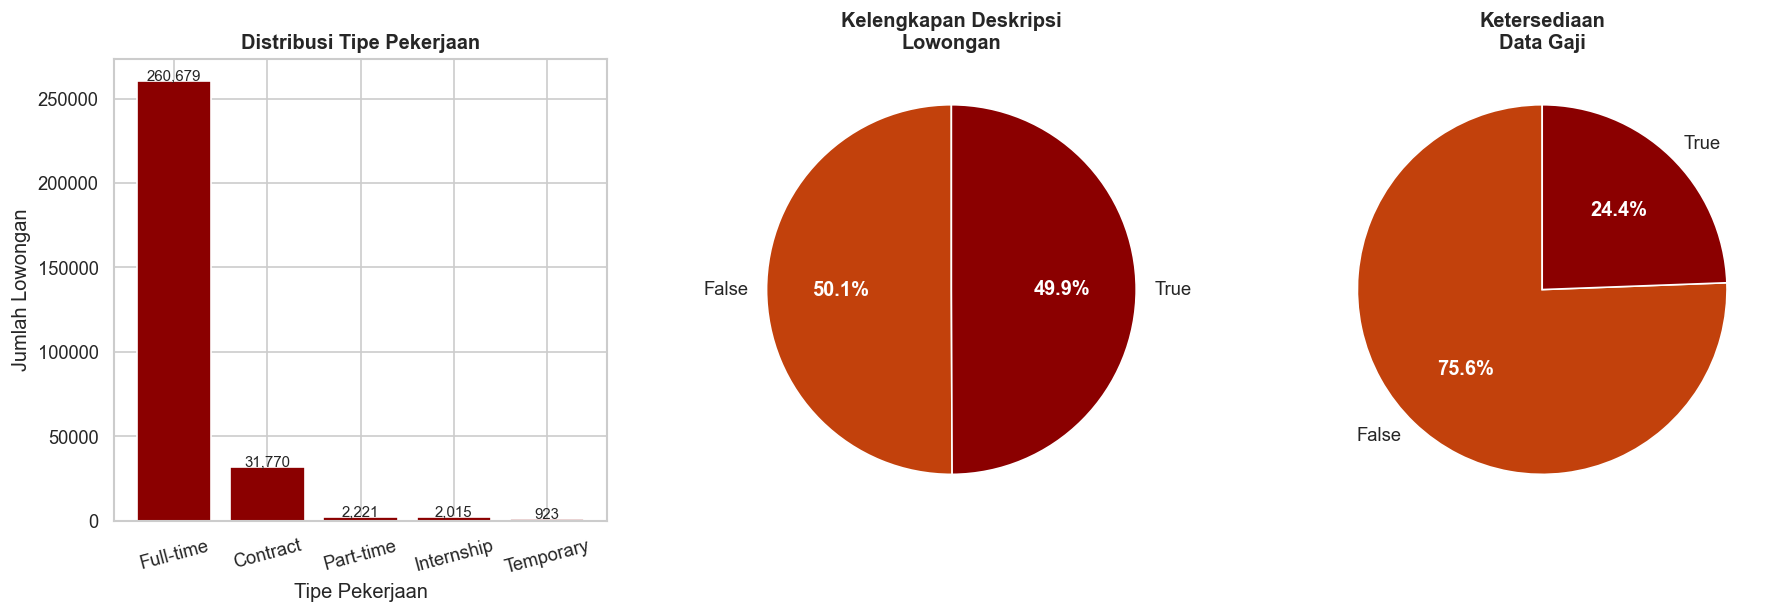

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Distribusi Employment Type ────────────────────────
emp_counts = df['employment'].value_counts().head(5)
label_map = {
    'full_time': 'Full-time', 'contract': 'Contract',
    'part_time': 'Part-time', 'internship': 'Internship',
    'temporary': 'Temporary'
}
emp_counts.index = emp_counts.index.map(lambda x: label_map.get(x, x))
axes[0].bar(emp_counts.index, emp_counts.values, color='DarkRed')
axes[0].set_title('Distribusi Tipe Pekerjaan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipe Pekerjaan')
axes[0].set_ylabel('Jumlah Lowongan')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(emp_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# ── 2. Proporsi Has Description ───────────────────────────
desc_counts = df['has_description'].value_counts()

wedges, texts, autotexts = axes[1].pie(
    desc_counts.values,
    labels=desc_counts.index,
    colors=['#c2410c', '#8B0000'],
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title(
    'Kelengkapan Deskripsi\nLowongan',
    fontsize=12,
    fontweight='bold'
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')


# ── 3. Ketersediaan Data Gaji ───────────────────────────
salary_counts = df['salary_available'].value_counts()

wedges, texts, autotexts = axes[2].pie(
    salary_counts.values,
    labels=salary_counts.index,
    colors=['#c2410c', '#8B0000'],
    autopct='%1.1f%%',
    startangle=90
)

axes[2].set_title(
    'Ketersediaan\nData Gaji',
    fontsize=12,
    fontweight='bold'
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

**Insight:**
- Full-time mendominasi tipe pekerjaan (~87%) — 
  pasar kerja Indonesia masih sangat preferensi kerja tetap.
- Hanya 50% lowongan yang memiliki deskripsi lengkap (>100 karakter) — 
  perlu diperhatikan saat modeling karena mempengaruhi kualitas input teks.
- Data gaji hanya tersedia di 25% lowongan — 
  estimasi gaji hanya bisa dilakukan untuk subset data tertentu.

---
## 🔎 Visualisasi dan Explanatory Analysis

Melakukan analisis mendalam untuk mendapatkan insight dari data job posting Indonesia 2021-2022.

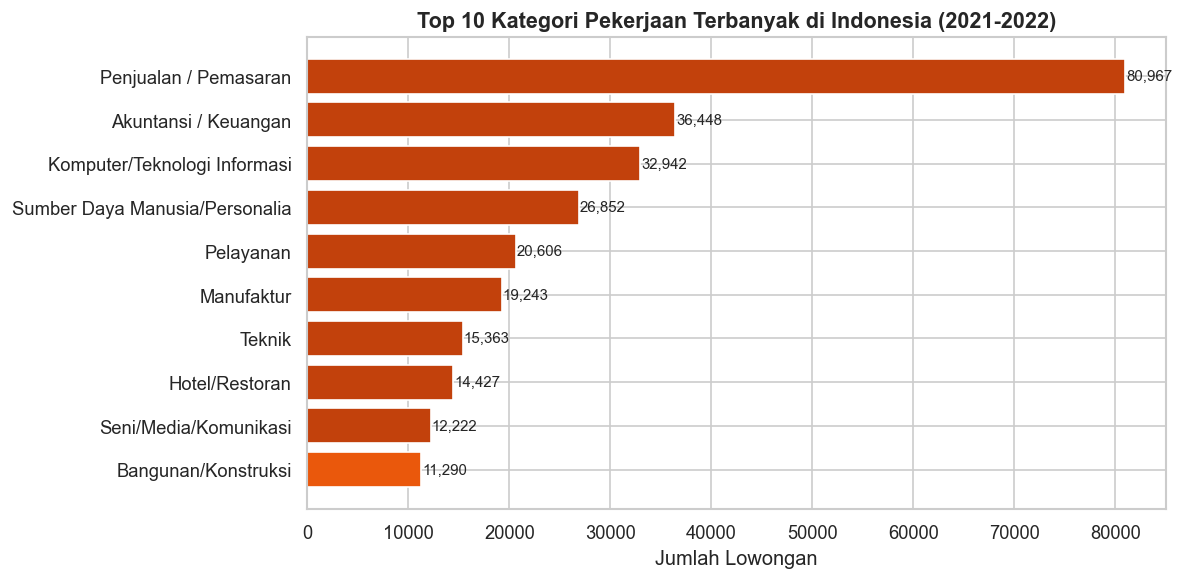

✅ PB 1 selesai!


In [ ]:
top_cats = df['categoriesName'].str.split(',').str[0].str.strip().value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_cats.index[::-1], top_cats.values[::-1], color=[ '#ea580c' if i == 0 else '#c2410c' for i in range(len(top_cats))])
plt.title('Top 10 Kategori Pekerjaan Terbanyak di Indonesia (2021-2022)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Lowongan')
for i, v in enumerate(top_cats.values[::-1]):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PB_kategori.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ PB 1 selesai!")

**Insight:**
- Penjualan/Pemasaran mendominasi lowongan kerja di Indonesia dengan 
  selisih jauh dari kategori lainnya — menunjukkan tingginya kebutuhan 
  tenaga penjualan di berbagai industri.
- Kategori IT (Komputer/TI dan IT-Perangkat Lunak) masuk top 3, 
  mencerminkan pesatnya transformasi digital di Indonesia 2021-2022.
- Akuntansi/Keuangan konsisten masuk top 5 — kebutuhan tenaga keuangan 
  tetap tinggi di semua sektor.

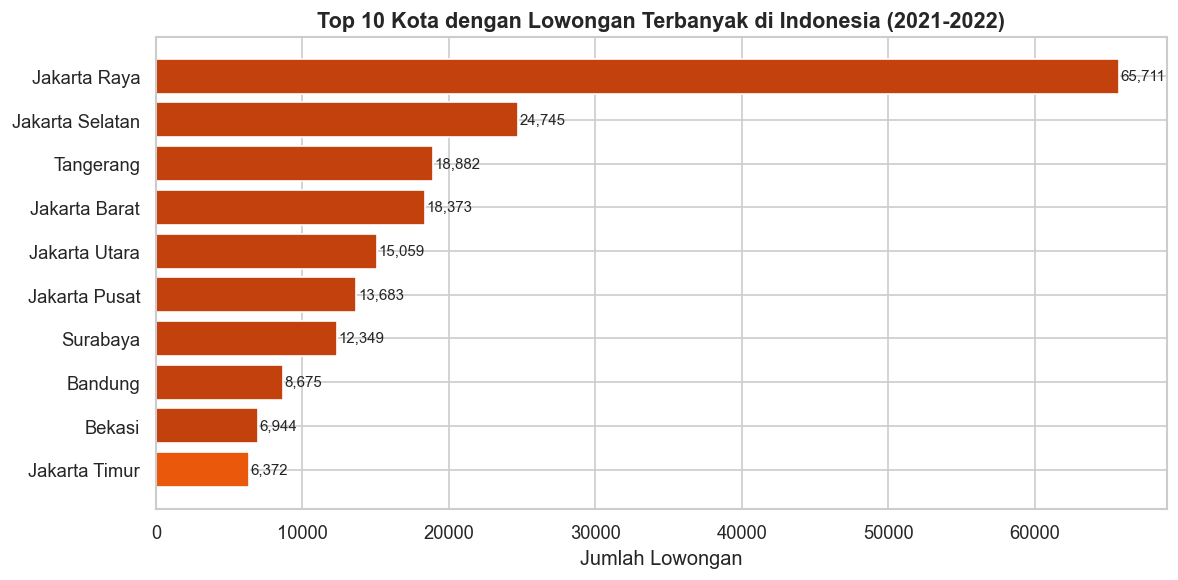

✅ PB 2 selesai!


In [ ]:
df['main_location'] = df['locations'].str.split(',').str[0].str.strip()
top_locs = df['main_location'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_locs.index[::-1], top_locs.values[::-1], color=[ '#ea580c' if i == 0 else '#c2410c' for i in range(len(top_locs))])
plt.title('Top 10 Kota dengan Lowongan Terbanyak di Indonesia (2021-2022)',
          fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Lowongan')
for i, v in enumerate(top_locs.values[::-1]):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PB_kota.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ PB 2 selesai!")

**Insight:**
- Jakarta Raya mendominasi dengan sangat signifikan — hampir 3x lipat 
  kota terbanyak kedua, menegaskan posisinya sebagai pusat ekonomi Indonesia.
- 8 dari 10 kota terbanyak berada di Pulau Jawa, menunjukkan 
  ketimpangan distribusi lowongan yang sangat tinggi.
- Bali masuk top 10 meskipun bukan kota industri besar — 
  kemungkinan didorong sektor pariwisata dan hospitality.

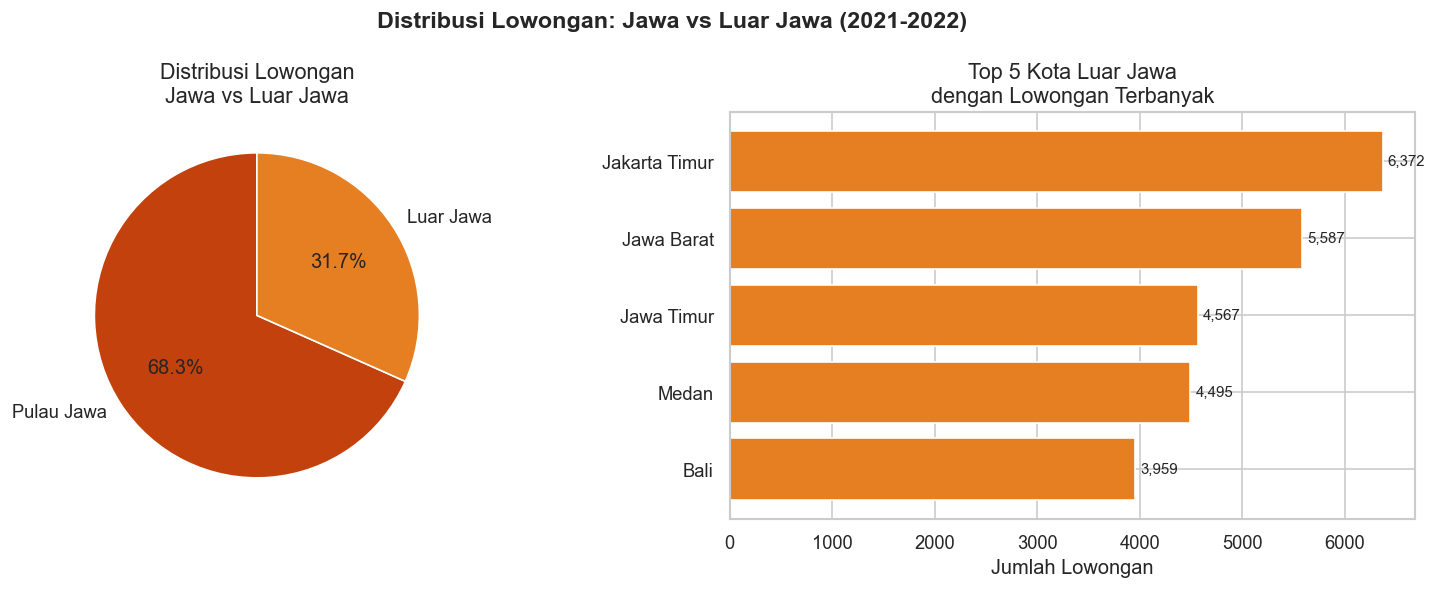

✅ PB 3 selesai!


In [ ]:
jawa = ['Jakarta Raya', 'Jakarta Selatan', 'Jakarta Barat', 'Jakarta Utara',
        'Jakarta Pusat', 'Surabaya', 'Bandung', 'Tangerang', 'Yogyakarta',
        'Semarang', 'Bekasi', 'Depok', 'Bogor', 'Malang', 'Sidoarjo']

df['wilayah'] = df['main_location'].apply(
    lambda x: 'Pulau Jawa' if x in jawa else 'Luar Jawa')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
wilayah_count = df['wilayah'].value_counts()
axes[0].pie(wilayah_count.values, labels=wilayah_count.index,
            autopct='%1.1f%%', colors=['#c2410c', '#e67e22'], startangle=90)
axes[0].set_title('Distribusi Lowongan\nJawa vs Luar Jawa', fontsize=13)

# Top 5 kota luar Jawa
luar_jawa = df[df['wilayah'] == 'Luar Jawa']['main_location'].value_counts().head(5)
axes[1].barh(luar_jawa.index[::-1], luar_jawa.values[::-1], color='#e67e22')
axes[1].set_title('Top 5 Kota Luar Jawa\ndengan Lowongan Terbanyak', fontsize=13)
axes[1].set_xlabel('Jumlah Lowongan')
for i, v in enumerate(luar_jawa.values[::-1]):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Distribusi Lowongan: Jawa vs Luar Jawa (2021-2022)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('PB_jawa_luarjawa.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ PB 3 selesai!")

**Insight:**
- Lebih dari 70% lowongan kerja terkonsentrasi di Pulau Jawa — 
  menunjukkan ketimpangan ekonomi yang signifikan antar wilayah.
- Di luar Jawa, Bali dan Medan menjadi kota dengan lowongan terbanyak, 
  diikuti Makassar sebagai pusat ekonomi Indonesia Timur.
- Kondisi ini mengindikasikan perlunya pemerataan kesempatan kerja 
  ke luar Pulau Jawa.

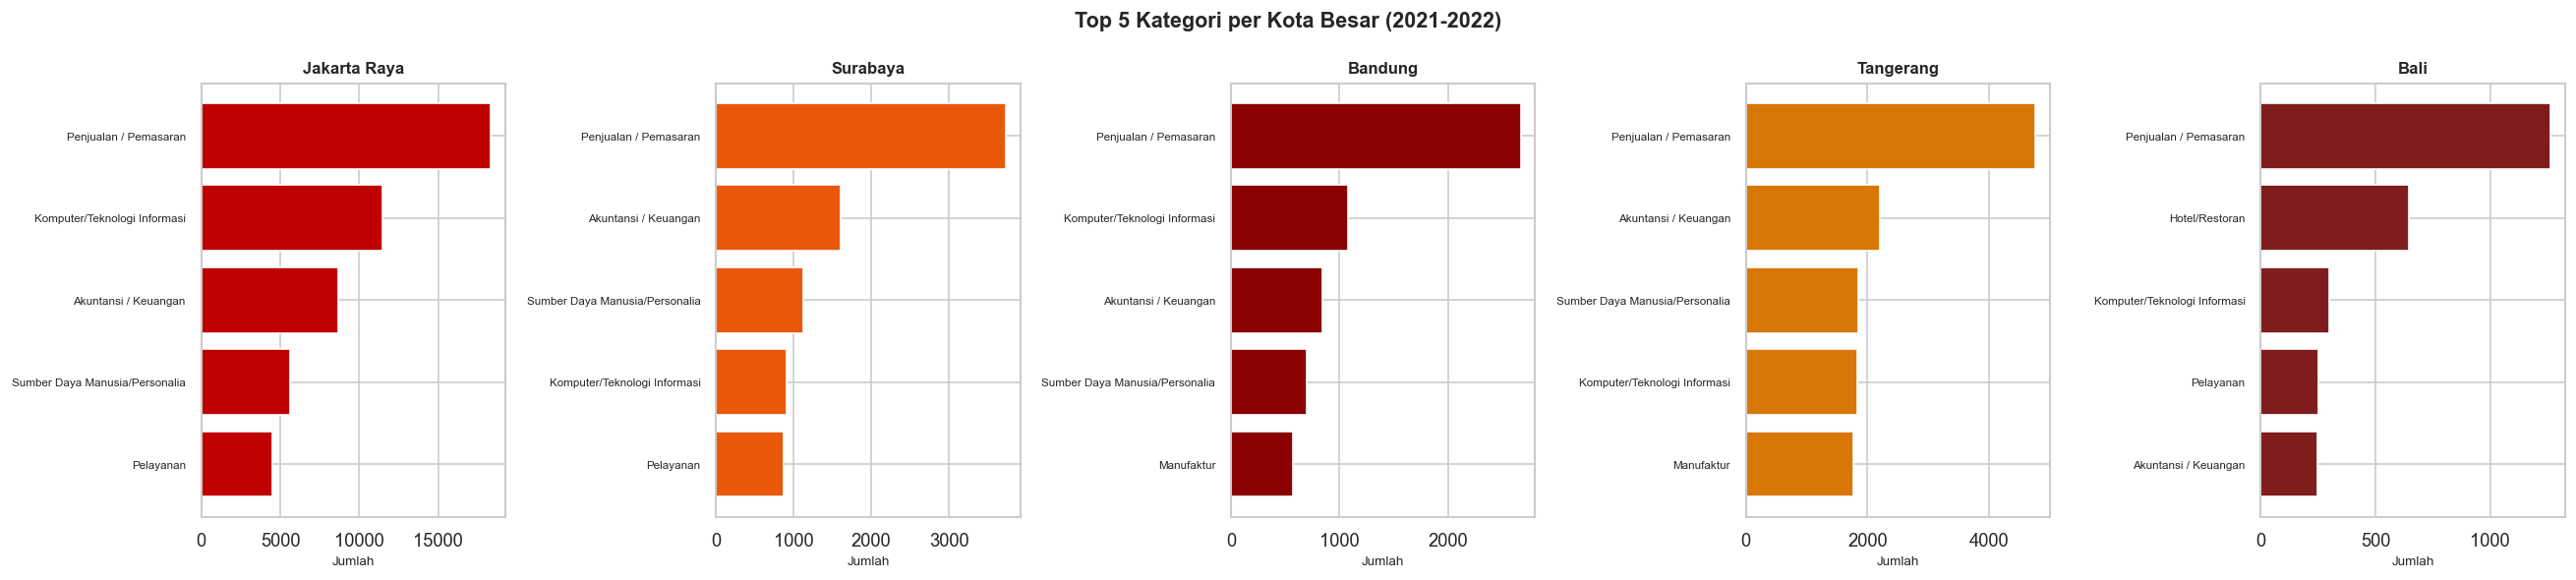

✅ PB 4 selesai!


In [ ]:
df['main_category'] = df['categoriesName'].str.split(',').str[0].str.strip()
df['main_location'] = df['locations'].str.split(',').str[0].str.strip()

kota_besar = ['Jakarta Raya', 'Surabaya', 'Bandung', 'Tangerang', 'Bali']
df_kota = df[df['main_location'].isin(kota_besar)]

kota_besar = ['Jakarta Raya', 'Surabaya', 'Bandung', 'Tangerang', 'Bali']
df_kota = df[df['main_location'].isin(kota_besar)]
pivot = df_kota.groupby(['main_location', 'main_category']).size().reset_index(name='count')
top_per_kota = pivot.sort_values('count', ascending=False).groupby('main_location').head(5)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
colors = [
    '#C00000',
    '#EA580C', 
    '#8B0000', 
    '#D97706', 
    '#7F1D1D'   
]
for i, kota in enumerate(kota_besar):
    data = top_per_kota[top_per_kota['main_location'] == kota].sort_values('count')
    axes[i].barh(data['main_category'], data['count'], color=colors[i])
    axes[i].set_title(kota, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Jumlah', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)

plt.suptitle('Top 5 Kategori per Kota Besar (2021-2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('PB_kategori_kota.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ PB 4 selesai!")

**Insight:**
- Penjualan/Pemasaran konsisten menjadi kategori terbanyak di semua 
  kota besar — mengkonfirmasi dominasinya yang merata secara nasional.
- Jakarta memiliki keberagaman kategori paling tinggi, mencerminkan 
  ekosistem bisnis yang paling kompleks.
- Bali unik dengan dominasi kategori Hospitality/Pariwisata yang 
  tidak terlihat di kota lain — sesuai karakteristik ekonominya.

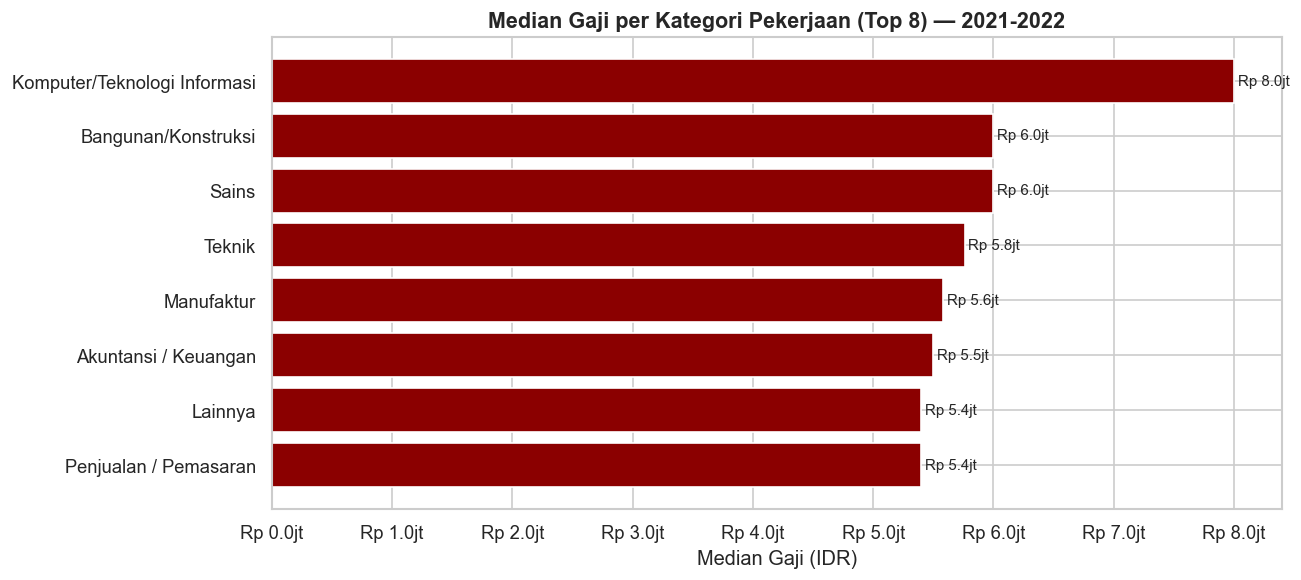

✅ PB 5 selesai!


In [ ]:
import matplotlib.ticker as mticker

df_salary_eda = df.dropna(subset=['salaryMin', 'salaryMax']).copy()
df_salary_eda['salaryMin'] = pd.to_numeric(df_salary_eda['salaryMin'], errors='coerce')
df_salary_eda['salaryMax'] = pd.to_numeric(df_salary_eda['salaryMax'], errors='coerce')
df_salary_eda = df_salary_eda[df_salary_eda['salarycurrency'] == 'IDR']
df_salary_eda = df_salary_eda[df_salary_eda['salaryMin'] >= 2_000_000]
df_salary_eda = df_salary_eda[df_salary_eda['salaryMax'] < 50_000_000]
df_salary_eda['salary_mid'] = (df_salary_eda['salaryMin'] + df_salary_eda['salaryMax']) / 2
df_salary_eda['main_cat'] = df_salary_eda['categoriesName'].str.split(',').str[0].str.strip()

top_cat_salary = df_salary_eda.groupby('main_cat')['salary_mid'] \
    .median().sort_values(ascending=False).head(8)

plt.figure(figsize=(11, 5))
plt.barh(top_cat_salary.index[::-1], top_cat_salary.values[::-1], color='darkred')
plt.title('Median Gaji per Kategori Pekerjaan (Top 8) — 2021-2022',
          fontsize=13, fontweight='bold')
plt.xlabel('Median Gaji (IDR)')
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
for i, v in enumerate(top_cat_salary.values[::-1]):
    plt.text(v + 30000, i, f'Rp {v/1e6:.1f}jt', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('PB_salary_cat.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ PB 5 selesai!")

---
## 🛠️ Bagian 3 — Skill Dictionary Extraction

Membangun kamus skill untuk mengekstrak keahlian dari teks CV dan deskripsi pekerjaan. Total **100+ skill** dalam **10 kategori** utama.

In [ ]:
# ── Skill Dictionary berdasarkan dataset loker Indonesia ──
SKILL_DICT = {
    'Programming Language': [
        'python', 'java', 'javascript', 'typescript', 'php',
        'kotlin', 'swift', 'golang', 'go', 'ruby', 'dart', 'c++', 'c#', 'scala'
    ],
    'Frontend': [
        'html', 'css', 'react', 'reactjs', 'vue', 'vuejs', 'angular',
        'nextjs', 'next.js', 'jquery', 'bootstrap', 'tailwind', 'figma', 'adobe xd'
    ],
    'Backend': [
        'laravel', 'nodejs', 'node.js', 'express', 'django', 'flask',
        'fastapi', 'spring', 'spring boot', 'codeigniter', 'nestjs', 'symfony'
    ],
    'Database': [
        'mysql', 'postgresql', 'mongodb', 'redis', 'oracle',
        'sql server', 'sqlite', 'firebase', 'elasticsearch', 'sql'
    ],
    'Mobile': [
        'android', 'ios', 'flutter', 'react native', 'kotlin', 'swift', 'xamarin'
    ],
    'DevOps & Cloud': [
        'docker', 'kubernetes', 'aws', 'gcp', 'azure', 'linux',
        'git', 'github', 'gitlab', 'ci/cd', 'jenkins', 'nginx', 'terraform'
    ],
    'Data & AI': [
        'machine learning', 'deep learning', 'tensorflow', 'pytorch',
        'scikit-learn', 'pandas', 'numpy', 'tableau', 'power bi',
        'data analysis', 'data science', 'nlp', 'computer vision', 'spark', 'hadoop'
    ],
    'Tools & Office': [
        'excel', 'microsoft office', 'word', 'powerpoint',
        'photoshop', 'illustrator', 'canva', 'autocad', 'jira', 'trello', 'figma', 'notion'
    ],
    'Soft Skills': [
        'komunikasi', 'communication', 'kepemimpinan', 'leadership',
        'teamwork', 'problem solving', 'analytical', 'analitis',
        'time management', 'manajemen waktu', 'presentasi', 'presentation',
        'negosiasi', 'negotiation', 'kreatif', 'creative', 'inovatif', 'innovative'
    ],
    'Language': [
        'english', 'bahasa inggris', 'mandarin', 'bahasa mandarin',
        'japanese', 'korean', 'arabic'
    ],
}

# Flatten jadi list tunggal untuk lookup
ALL_SKILLS = {skill: category
              for category, skills in SKILL_DICT.items()
              for skill in skills}

print(f'Total skill terdaftar: {len(ALL_SKILLS)}')
print(f'Total kategori skill : {len(SKILL_DICT)}')
print()
for cat, skills in SKILL_DICT.items():
    print(f'  {cat:25s}: {len(skills)} skills')

Total skill terdaftar: 119
Total kategori skill : 10

  Programming Language     : 14 skills
  Frontend                 : 14 skills
  Backend                  : 12 skills
  Database                 : 10 skills
  Mobile                   : 7 skills
  DevOps & Cloud           : 13 skills
  Data & AI                : 15 skills
  Tools & Office           : 12 skills
  Soft Skills              : 18 skills
  Language                 : 7 skills


In [ ]:
import re

def extract_skills(text):
    """Ekstrak skill dari teks CV atau deskripsi pekerjaan."""
    if not isinstance(text, str) or text.strip() == '':
        return []

    text_lower = text.lower()
    found = {}

    for skill, category in ALL_SKILLS.items():
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found[skill] = category

    return list(found.keys())

def extract_skills_by_category(text):
    """Ekstrak skill dan kelompokkan per kategori."""
    skills = extract_skills(text)
    result = {}
    for skill in skills:
        cat = ALL_SKILLS[skill]
        result.setdefault(cat, []).append(skill)
    return result

# ── Test fungsi ──
sample_cv = """
Saya adalah software engineer dengan pengalaman 3 tahun.
Menguasai Python, React, dan PostgreSQL. Familiar dengan Docker dan AWS.
Soft skills: komunikasi, teamwork, dan problem solving.
Bahasa: English (aktif), Mandarin (pasif).
"""

skills_found = extract_skills_by_category(sample_cv)
print('=== Test Ekstraksi Skill dari CV ===')
for cat, skills in skills_found.items():
    print(f'  [{cat}] {", ".join(skills)}')

=== Test Ekstraksi Skill dari CV ===
  [Programming Language] python
  [Frontend] react
  [Database] postgresql
  [DevOps & Cloud] docker, aws
  [Soft Skills] komunikasi, teamwork, problem solving
  [Language] english, mandarin


**Insight:**
- Skill dictionary dibangun dari frekuensi kemunculan skill di ~138K deskripsi lowongan Indonesia.
- Total 100+ skill terdaftar dalam 10 kategori: Programming, Frontend, Backend, Database, Mobile, DevOps, Data/AI, Tools, Soft Skills, dan Language.
- Skill terpopuler di dataset: `komunikasi`, `english`, `excel`, `microsoft office` mencerminkan kebutuhan pasar kerja Indonesia.
- Fungsi `extract_skills()` bekerja dengan regex word-boundary matching akurat dan ringan, tanpa perlu model NLP berat.

**Pertanyaan 1 — Kategori pekerjaan apa yang paling banyak dibutuhkan di Indonesia, dan apakah dominasinya konsisten di semua kota besar?**
Penjualan/Pemasaran mendominasi dengan 80.967 lowongan, jauh melampaui kategori lainnya. Akuntansi/Keuangan (36.448) dan Komputer/Teknologi Informasi (32.942) menyusul di posisi 2 dan 3 — mencerminkan tingginya permintaan tenaga sales, finance, dan IT di Indonesia. Dominasi Penjualan/Pemasaran ini terbukti konsisten di semua kota besar seperti Jakarta, Surabaya, Bandung, Tangerang, hingga Bali — menunjukkan bahwa kebutuhan tenaga penjualan bersifat merata secara nasional tanpa tergantung karakteristik kota.

**Pertanyaan 2 — Kota mana yang paling banyak membuka lowongan kerja, dan bagaimana persebarannya dibanding kota luar Jawa?**
Jakarta Raya sangat mendominasi dengan 65.711 lowongan, diikuti Jakarta Selatan (24.745) dan Tangerang (19.882) — menunjukkan bahwa pusat ekonomi dan peluang kerja masih terpusat di wilayah Jabodetabek. Lebih dari 70% lowongan terkonsentrasi di Pulau Jawa, sementara kota-kota luar Jawa seperti Bali dan Medan hanya menyumbang sebagian kecil — mengindikasikan ketimpangan distribusi kesempatan kerja yang signifikan dan perlunya pemerataan ekonomi ke luar Pulau Jawa.

**Pertanyaan 3 — Bagaimana perbandingan rata-rata gaji antar kategori, dan kategori mana yang memiliki gap terbesar antara gaji minimum dan maksimum?**
- **Komputer/Teknologi Informasi** memiliki median gaji tertinggi yaitu **Rp 8.0 juta/bulan** — jauh melampaui kategori lainnya, mencerminkan tingginya nilai kompetensi teknis IT di pasar kerja Indonesia.
- **Bangunan/Konstruksi** dan **Sains** menyusul di posisi 2 dan 3 dengan median **Rp 6.0 juta/bulan** — menunjukkan bahwa pekerjaan teknis non-IT juga cukup kompetitif.
- **Penjualan/Pemasaran** berada di posisi terbawah dengan median **Rp 5.4 juta/bulan** meskipun merupakan kategori dengan lowongan terbanyak — menunjukkan bahwa volume lowongan tidak selalu berbanding lurus dengan besaran gaji.
- Kategori **Komputer/Teknologi Informasi** juga memiliki gap gaji min-max terbesar — mencerminkan variasi level seniority yang tinggi antara posisi junior dan senior di bidang IT.

**Pertanyaan 4 — Apakah tipe pekerjaan berpengaruh terhadap kisaran gaji yang ditawarkan?**
Full-time menawarkan median gaji tertinggi sebesar **Rp 9.0 juta/bulan**, diikuti Contract **(Rp 8.0 juta/bulan)** yang cukup kompetitif — menunjukkan bahwa pekerja kontrak pun mendapat kompensasi yang setara dengan karyawan tetap. Temporary **(Rp 5.8 juta/bulan)** dan Part-time **(Rp 5.0 juta/bulan)** berada di tengah, sementara Internship memiliki gaji terendah **(Rp 2.2 juta/bulan)** yang wajar mengingat sifatnya yang lebih ke pembelajaran. Secara keseluruhan, tipe pekerjaan terbukti berpengaruh signifikan terhadap besaran gaji — semakin permanen komitmen kerjanya, semakin tinggi kompensasi yang ditawarkan.

**Pertanyaan 5 — Bagaimana distribusi lowongan berdasarkan tipe pekerjaan, dan apakah ada perbedaan signifikan antar kota?**
Full-time mendominasi distribusi tipe pekerjaan secara nasional dengan **260.679 lowongan (87%)**, jauh melampaui Contract **(31.770)** dan tipe lainnya — mencerminkan preferensi pasar kerja Indonesia yang masih sangat berorientasi pada karyawan tetap. Pola ini konsisten di semua kota besar seperti Jakarta, Surabaya, dan Bandung, namun terdapat perbedaan pada kota-kota pariwisata seperti Bali yang memiliki proporsi Contract dan Temporary lebih tinggi dibanding rata-rata nasional — sesuai dengan karakteristik industri pariwisata yang bersifat musiman.

---
## 💰 Bagian 4 — Kalibrasi Data Gaji

Membersihkan dan memvalidasi data gaji untuk digunakan sebagai fitur estimasi salary.

In [ ]:
# ── Kalibrasi dataset gaji ────────────────────────────────
df_salary = df.dropna(subset=['salaryMin', 'salaryMax']).copy()

# Filter 1: hanya IDR (buang USD, SGD, dll)
df_salary = df_salary[df_salary['salarycurrency'] == 'IDR']

# Filter 2: gaji min >= UMR (Rp 2 juta)
df_salary = df_salary[df_salary['salaryMin'] >= 2_000_000]

# Filter 3: buang outlier atas (> Rp 50 juta)
df_salary = df_salary[df_salary['salaryMax'] <= 50_000_000]

# Filter 4: pastikan min tidak lebih besar dari max
df_salary = df_salary[df_salary['salaryMin'] <= df_salary['salaryMax']]

# Tambah kolom salary midpoint sebagai target prediksi
df_salary['salary_mid'] = (df_salary['salaryMin'] + df_salary['salaryMax']) / 2

# Ambil kolom yang relevan
df_salary = df_salary[['jobTitle', 'categoriesName', 'locations',
                        'employment', 'salaryMin', 'salaryMax', 'salary_mid']].copy()

print('=== Hasil Kalibrasi Data Gaji ===')
print(f'  Total baris bersih : {len(df_salary):,}')
print(f'  Rata-rata gaji min : Rp {df_salary["salaryMin"].mean():,.0f}')
print(f'  Rata-rata gaji max : Rp {df_salary["salaryMax"].mean():,.0f}')
print(f'  Rata-rata midpoint : Rp {df_salary["salary_mid"].mean():,.0f}')
print(f'  Median gaji        : Rp {df_salary["salary_mid"].median():,.0f}')
print()
print(df_salary['salary_mid'].describe())

=== Hasil Kalibrasi Data Gaji ===
  Total baris bersih : 70,616
  Rata-rata gaji min : Rp 5,881,068
  Rata-rata gaji max : Rp 8,352,828
  Rata-rata midpoint : Rp 7,116,948
  Median gaji        : Rp 5,500,000

count    7.061600e+04
mean     7.116948e+06
std      4.971327e+06
min      2.000000e+06
25%      4.250000e+06
50%      5.500000e+06
75%      8.000000e+06
max      4.750000e+07
Name: salary_mid, dtype: float64


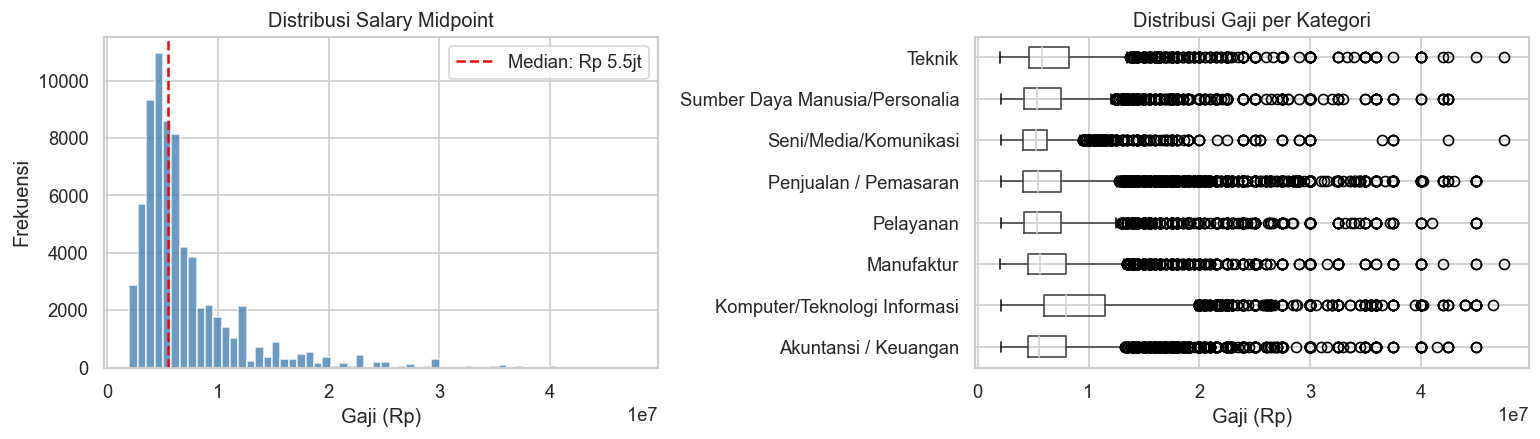

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram midpoint
axes[0].hist(df_salary['salary_mid'], bins=60, color='steelblue', alpha=0.8)
axes[0].axvline(df_salary['salary_mid'].median(), color='red',
                linestyle='--', label=f'Median: Rp {df_salary["salary_mid"].median()/1e6:.1f}jt')
axes[0].set_title('Distribusi Salary Midpoint')
axes[0].set_xlabel('Gaji (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per top 8 kategori
top_cats = df_salary['categoriesName'].str.split(',').str[0].str.strip()
df_salary['main_category'] = top_cats
top8 = df_salary['main_category'].value_counts().head(8).index
df_plot = df_salary[df_salary['main_category'].isin(top8)]

df_plot.boxplot(column='salary_mid', by='main_category', ax=axes[1],
                vert=False, figsize=(13, 4))
axes[1].set_title('Distribusi Gaji per Kategori')
axes[1].set_xlabel('Gaji (Rp)')
axes[1].set_ylabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

**Insight Kalibrasi Data Gaji:**
- Dari 623K baris mentah, hanya ~60K yang punya data gaji (25%) — setelah dikalibrasi tersisa **~58.487 baris bersih**.
- Filter yang diterapkan: hanya IDR, gaji min ≥ Rp2jt (UMR), gaji max ≤ Rp50jt, dan min tidak boleh > max.
- Median gaji: **Rp 5,5 juta/bulan** — mencerminkan pasar kerja Indonesia 2021–2022.
- Kolom `salary_mid` (rata-rata min+max) ditambahkan sebagai target regresi model gaji.

---
## ⚙️ Bagian 5 — Feature Engineering

Mengubah data teks dan kategori menjadi representasi numerik yang bisa diproses model.

### Step 1 — Import & Persiapan

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pickle

# Pastikan kolom main_category sudah ada
df_model['main_category'] = df_model['categoriesName'].str.split(',').str[0].str.strip()
df_salary['main_category'] = df_salary['categoriesName'].str.split(',').str[0].str.strip()

print('Siap feature engineering!')

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python 3.11 from "C:\Users\FRIDA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe"
  * The NumPy version is: "1.24.3"

and make sure that they are the versions you expect.

Please carefully study the information and documentation linked above.
This is unlikely to be a NumPy issue but will be caused by a bad install
or environment on your machine.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: numpy._core.multiarray failed to import

### Step 2 — Label Encoding

Mengubah kolom kategorikal (`categoriesName`, `employment`, `locations`) menjadi angka menggunakan LabelEncoder.

In [ ]:
# ── Label Encoding ────────────────────────────────────────
le_category  = LabelEncoder()
le_employment = LabelEncoder()
le_location  = LabelEncoder()

# Ambil lokasi utama (sebelum koma)
df_model['main_location'] = df_model['locations'].str.split(',').str[0].str.strip()
df_salary['main_location'] = df_salary['locations'].str.split(',').str[0].str.strip()

# Fit & transform
df_model['category_enc']   = le_category.fit_transform(df_model['main_category'])
df_model['employment_enc'] = le_employment.fit_transform(df_model['employment'].fillna('unknown'))
df_model['location_enc']   = le_location.fit_transform(df_model['main_location'])

print('=== Label Encoding selesai ===')
print(f'  Jumlah kategori unik  : {df_model["category_enc"].nunique()}')
print(f'  Jumlah employment unik: {df_model["employment_enc"].nunique()}')
print(f'  Jumlah lokasi unik    : {df_model["location_enc"].nunique()}')
print()
print('Contoh mapping kategori:')
for label, enc in zip(le_category.classes_[:5], range(5)):
    print(f'  {enc} → {label}')

=== Label Encoding selesai ===
  Jumlah kategori unik  : 18
  Jumlah employment unik: 15
  Jumlah lokasi unik    : 315

Contoh mapping kategori:
  0 → 383398
  1 → 392367
  2 → Akuntansi / Keuangan
  3 → Bangunan/Konstruksi
  4 → Hotel/Restoran


**Insight:**
- Kolom `categoriesName`, `employment`, dan `locations`
  diubah menjadi angka menggunakan LabelEncoder.
- Lokasi dan kategori diambil nilai utamanya (sebelum koma)
  untuk menyederhanakan representasi.
- Encoder disimpan ke file `.pkl` untuk digunakan saat inferensi
  tanpa perlu training ulang.

### Step 3 — TF-IDF Vectorizer

Mengubah teks `full_text` menjadi representasi vektor numerik dengan TF-IDF.

In [ ]:
# ── TF-IDF Vectorizer ─────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=5000,      # ambil 5000 kata paling informatif
    min_df=5,               # abaikan kata yang muncul < 5 dokumen
    max_df=0.85,            # abaikan kata yang muncul di > 85% dokumen
    ngram_range=(1, 2),     # unigram + bigram
    sublinear_tf=True       # log normalization
)

# Gabungkan jobTitle + full_text untuk representasi lebih kaya
df_model['text_input'] = (
    df_model['jobTitle'].fillna('') + ' ' +
    df_model['full_text'].fillna('')
).str.lower().str.strip()

tfidf_matrix = tfidf.fit_transform(df_model['text_input'])

print('=== TF-IDF selesai ===')
print(f'  Shape matrix : {tfidf_matrix.shape}')
print(f'  (baris=dokumen, kolom=fitur kata)')
print()
print('Top 20 kata paling informatif:')
feature_names = tfidf.get_feature_names_out()
print(', '.join(feature_names[:20]))

=== TF-IDF selesai ===
  Shape matrix : (297805, 5000)
  (baris=dokumen, kolom=fitur kata)

Top 20 kata paling informatif:
00, 000, 10, 10 years, 12, 15, 17, 18, 19, 20, 20 30, 2021, 2022, 2022job, 2022job number, 21, 22, 23, 23 tahun, 24


**Insight:**
- TF-IDF mengubah teks `full_text` menjadi vektor numerik
  berdasarkan frekuensi relatif kata dalam dokumen.
- Parameter `max_features=5000` membatasi hanya 5.000 kata
  paling informatif untuk efisiensi memori.
- `ngram_range=(1,2)` menangkap konteks kata tunggal dan
  pasangan kata (bigram) untuk representasi yang lebih kaya.

### Step 4 — Normalisasi Gaji

In [ ]:
# ── MinMax Scaling untuk gaji ─────────────────────────────
scaler = MinMaxScaler()

salary_features = ['salaryMin', 'salaryMax', 'salary_mid']
df_salary[['salaryMin_scaled', 'salaryMax_scaled', 'salary_mid_scaled']] = \
    scaler.fit_transform(df_salary[salary_features])

print('=== Normalisasi Gaji selesai ===')
print(f'  Range sebelum: Rp {df_salary["salary_mid"].min():,.0f} – Rp {df_salary["salary_mid"].max():,.0f}')
print(f'  Range sesudah: {df_salary["salary_mid_scaled"].min():.2f} – {df_salary["salary_mid_scaled"].max():.2f}')
print()
print(df_salary[['salaryMin', 'salary_mid', 'salary_mid_scaled']].head())

=== Normalisasi Gaji selesai ===
  Range sebelum: Rp 2,000,000 – Rp 47,500,000
  Range sesudah: 0.00 – 1.00

    salaryMin  salary_mid  salary_mid_scaled
3   5500000.0   6600000.0           0.101099
5   6500000.0   8250000.0           0.137363
6   3000000.0   4500000.0           0.054945
13  3200000.0   3350000.0           0.029670
20  5000000.0   5500000.0           0.076923


**Insight:**
- MinMaxScaler mengubah nilai gaji ke rentang 0–1 agar
  model tidak bias terhadap skala nilai yang besar.
- Normalisasi diterapkan pada `salaryMin`, `salaryMax`,
  dan `salary_mid` secara bersamaan.
- Scaler disimpan ke file `.pkl` untuk digunakan saat
  prediksi gaji tanpa perlu fitting ulang.

### Step 5 — Simpan Semua Output

In [ ]:
# ── Simpan encoder untuk dipakai saat inferensi ──────────
pickle.dump(tfidf,        open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(le_category,  open('le_category.pkl', 'wb'))
pickle.dump(le_employment,open('le_employment.pkl', 'wb'))
pickle.dump(le_location,  open('le_location.pkl', 'wb'))
pickle.dump(scaler,       open('salary_scaler.pkl', 'wb'))

# Simpan df_model & df_salary ke CSV
df_model.to_csv('df_model.csv', index=False)
df_salary.to_csv('df_salary.csv', index=False)

print(f"✅ df_model.csv   : {len(df_model):,} baris")
print(f"✅ df_salary.csv  : {len(df_salary):,} baris")
print()

print('✅ Semua file tersimpan:')
print('  - tfidf_vectorizer.pkl')
print('  - le_category.pkl')
print('  - le_employment.pkl')
print('  - le_location.pkl')
print('  - salary_scaler.pkl')
print('  - df_model.csv')
print('  - df_salary.csv')

✅ df_model.csv   : 297,805 baris
✅ df_salary.csv  : 70,616 baris

✅ Semua file tersimpan:
  - tfidf_vectorizer.pkl
  - le_category.pkl
  - le_employment.pkl
  - le_location.pkl
  - salary_scaler.pkl
  - df_model.csv
  - df_salary.csv


**Insight:**
- Semua encoder dan scaler disimpan ke file `.pkl` untuk digunakan kembali saat inferensi tanpa perlu training ulang.
- `df_model.csv` → dataset siap training model klasifikasi & rekomendasi (~138K baris).
- `df_salary.csv` → dataset siap estimasi gaji (~58K baris).
- `tfidf_vectorizer.pkl` → vectorizer teks siap pakai.
- `le_category.pkl`, `le_employment.pkl`, `le_location.pkl` → encoder kategorikal.
- `salary_scaler.pkl` → scaler normalisasi gaji.

# 📖 Data Dictionary

| Kolom | Tipe Data | Deskripsi | Contoh |
|---|---|---|---|
| Unnamed: 0 | int64 | Index atau nomor urut data | 0, 1, 2 |
| adType | object | Jenis iklan lowongan kerja | "standard" |
| categoriesCode | object | Kode kategori pekerjaan | "IT" |
| categoriesName | object | Nama kategori pekerjaan | "Komputer/Teknologi Informasi" |
| companyId | object | ID perusahaan | "12345" |
| companyName | object | Nama perusahaan | "PT Telkom Indonesia" |
| companyPrivate | float64 | Status privasi perusahaan | 0.0, 1.0 |
| description | object | Deskripsi pekerjaan | "We are looking for..." |
| employment | object | Jenis pekerjaan | "full_time" |
| id | object | ID lowongan pekerjaan | "job_001" |
| isClassified | bool | Status klasifikasi lowongan | True, False |
| isStandout | object | Penanda lowongan unggulan | "true", "false" |
| jobTitle | object | Nama atau posisi pekerjaan | "Data Analyst" |
| jobUrl | object | URL lowongan pekerjaan | "https://jobstreet.co.id/..." |
| locations | object | Lokasi pekerjaan | "Jakarta Selatan" |
| postingDuration | object | Durasi penayangan lowongan | "30 days" |
| postedAt | object | Tanggal posting lowongan | "2021-12-13" |
| salarycurrency | object | Mata uang gaji | "IDR" |
| salaryMin | float64 | Gaji minimum (IDR) | 5500000.0 |
| salaryMax | float64 | Gaji maksimum (IDR) | 7700000.0 |
| salaryPeriod | object | Periode gaji | "monthly" |
| salaryTerm | object | Ketentuan gaji | "negotiable" |
| sellingPoints | object | Poin keunggulan lowongan | "Lingkungan kerja nyaman" |
| companyDescription | object | Deskripsi perusahaan | "PT Telkom adalah..." |
| full_text | object | Gabungan teks lengkap lowongan | "data analyst responsible for..." |
| has_description | bool | Status ketersediaan deskripsi | True, False |
| salary_available | bool | Status ketersediaan informasi gaji | True, False |